# 0. Import and Install Libraries

## Installs

In [1]:
# !pip install yellowbrick

In [2]:
# !pip install graphviz

## Imports

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sbn

# 1. Research Goals

## Problem statement
This project investigates which factors most strongly influence housing prices in Melbourne and whether housing prices can be predicted reliably using property and location data.

## Context
The Melbourne housing market is influenced by both structural property features and geographic location. Understanding which factors drive housing prices is important for buyers, sellers, and analysts. This dataset makes it possible to examine price patterns and test whether housing prices can be predicted from available variables.

## Goals
The goal of this project is to investigate the main determinants of housing prices in Melbourne and to build a predictive model that estimates house prices based on housing characteristics and location.

## Research questions
* Which factors are the strongest predictors of housing price?
* How does location affect housing prices across Melbourne?
* How do housing prices differ between property types?
* To what extent can machine learning predict housing prices accurately?

## Hypotheses
* Housing prices increase with size, number of rooms, and number of bathrooms.
* Properties located closer to the city center are more expensive.
* Houses are more expensive than units and townhouses.
* Location-based features contribute significantly to price prediction.
* A machine learning model can predict housing prices with useful accuracy.


# 2. Retrieve Data

## 2.1 Melbourne Data

The data is originally scraped from Domain.com.au. and the uploaded to Kaggle.com

In [7]:
df_melb = pd.read_csv(r"C:\Users\Administrator\BI\Melbourne\data\melb_data.csv")

### Data Dictionary
| Variable | Description |
| :--- | :--- |
| **Rooms** | Number of rooms |
| **Price** | Price in dollars |
| **Method** | S - property sold; SP - property sold prior; PI - property passed in; PN - sold prior not disclosed; SN - sold not disclosed; NB - no bid; VB - vendor bid; W - withdrawn prior to auction; SA - sold after auction; SS - sold after auction price not disclosed. N/A - price or highest bid not available. |
| **Type** | br - bedroom(s); h - house, cottage, villa, semi, terrace; u - unit, duplex; t - townhouse; dev site - development site; o res - other residential. |
| **SellerG** | Real Estate Agent |
| **Date** | Date sold |
| **Distance** | Distance from CBD |
| **Regionname** | General Region (West, North West, North, North east …etc) |
| **Propertycount** | Number of properties that exist in the suburb. |
| **Bedroom2** | Scraped # of Bedrooms (from different source) |
| **Bathroom** | Number of Bathrooms |
| **Car** | Number of carspots |
| **Landsize** | Land Size |
| **BuildingArea** | Building Size |
| **CouncilArea** | Governing council for the area |

## 2.2 Denmark Data

# 3. Data Preparation - Melbourne Data

## 3.1 Data Inspection

Quick inspection of the dataset, to see what needs cleaning

In [8]:
# Check rows and columns
df_melb.shape

(13580, 21)

In [9]:
# Random samples to get a quick overview of the data
df_melb.sample(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
8180,Oak Park,126A Winifred St,3,h,755000.0,SP,Eview,8/04/2017,11.5,3046.0,...,2.0,1.0,341.0,170.0,2003.0,Moreland,-37.71660,144.91040,Northern Metropolitan,2651.0
2789,Glen Iris,20 Howitt St,4,h,2376000.0,S,Jellis,12/11/2016,9.2,3146.0,...,2.0,2.0,652.0,230.0,1925.0,Boroondara,-37.84790,145.05570,Southern Metropolitan,10412.0
10149,Brighton East,181 Dendy St,4,h,2300000.0,VB,Biggin,27/05/2017,10.3,3187.0,...,3.0,2.0,592.0,NaN,NaN,Bayside,-37.92173,145.01436,Southern Metropolitan,6938.0
13057,Sunshine North,19A Park Dr,3,h,502500.0,S,Douglas,19/08/2017,10.5,3020.0,...,1.0,3.0,331.0,123.0,1995.0,NaN,-37.75962,144.82596,Western Metropolitan,4217.0
585,Balwyn North,3/41 Clifton St,3,t,1315000.0,S,hockingstuart,3/09/2016,9.2,3104.0,...,2.0,2.0,260.0,167.0,2000.0,Boroondara,-37.79660,145.10210,Southern Metropolitan,7809.0


In [10]:
# Check the datatypes
df_melb.dtypes

Suburb               str
Address              str
Rooms              int64
Type                 str
Price            float64
Method               str
SellerG              str
Date                 str
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea          str
Lattitude        float64
Longtitude       float64
Regionname           str
Propertycount    float64
dtype: object

In [11]:
# Check to see how many unique values there is for each column, to see if some columns can be dropped
df_melb.nunique()

Suburb             314
Address          13378
Rooms                9
Type                 3
Price             2204
Method               5
SellerG            268
Date                58
Distance           202
Postcode           198
Bedroom2            12
Bathroom             9
Car                 11
Landsize          1448
BuildingArea       602
YearBuilt          144
CouncilArea         33
Lattitude         6503
Longtitude        7063
Regionname           8
Propertycount      311
dtype: int64

In [12]:
# Check to see if there are duplicated rows
df_melb.duplicated().sum()

np.int64(0)

In [13]:
# Check to see if there are missing values
df_melb.isna().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [14]:
# Check of the descriptive statistics to check for odd values
df_melb.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


### Data Inspection Findings

We have observed the following that needs further examination and/or cleaning:

* 'Rooms' (from original source) vs 'Bedroom2' (from other source)

   Both colums contains nearly the same means (2.94 vs 2.91) and identical quartiles. However we can also see that in 'Bedroom2' the min value is 0       rooms and the max is 20 rooms vs 1 and 10 in 'Rooms', so there are some clear outliers in 'Bedroom2'. So to avoid redundant data we will drop the      'Bedroom2' column and keep the data that was scraped the same place as all the other columns.
  
* Possible Outliers and/or errors
  -  Some properties have 0 'Bathrooms', which is possible with fx. shared bathrooms, but it seems unlikely.
  -  Some properties have a 'Landsize' of 0 while the max value is 433 014 m2.
  -  Some properties have a 'BuildingArea' of 0 while the max value is 44 515 m2
  -  There is a property built in year 1196, which is highly unlikely in Austrailia therefore likely an error


* Columns with missing values:
  - 'Car' has 62 missing values
  - 'BuildingArea' has 6450 missing values
  - 'YearBuilt' has 5375 missing values
  - 'CouncilArea' has 1269 missing values

## 3.2 Data Cleaning

In [15]:
df_melb_clean = df_melb.copy()

### Drop column 'Bedroom2'


In [16]:
df_melb_clean = df_melb_clean.drop(columns='Bedroom2')

## 3.3 Removing Outliers
We will remove outliers for large building, properties and the most expensive houses so our models will be better at predicting the price of more normal houses for the everyday people

In [17]:
# The columns we will remove outliers from, but only if they are not NaN
df_melb_clean = df_melb_clean[
    ((df_melb_clean['Landsize'] < 5000) | (df_melb_clean['Landsize'].isna())) & 
    ((df_melb_clean['BuildingArea'] < 1000) | (df_melb_clean['BuildingArea'].isna())) &
    (df_melb_clean['Price'] < 5000000)
]


print(df_melb.shape)
print(df_melb_clean.shape)

(13580, 21)
(13489, 20)


### Price
Effects of the outlier removal

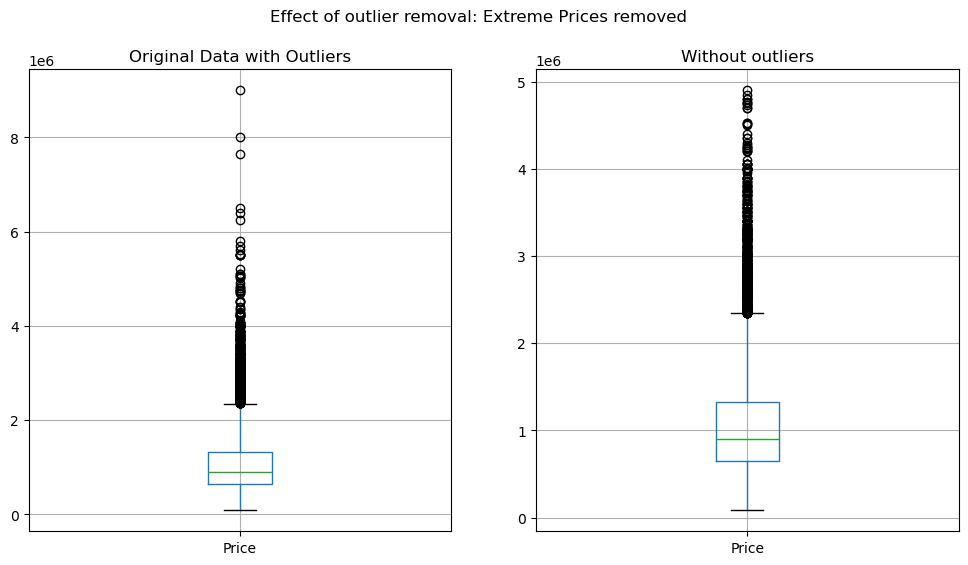

In [18]:
# Boxplots of before and after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Effect of outlier removal: Extreme Prices removed')

df_melb.boxplot(column=['Price'], ax=axes[0])
axes[0].set_title('Original Data with Outliers')

df_melb_clean.boxplot(column=['Price'], ax=axes[1])
axes[1].set_title('Without outliers')

plt.show()

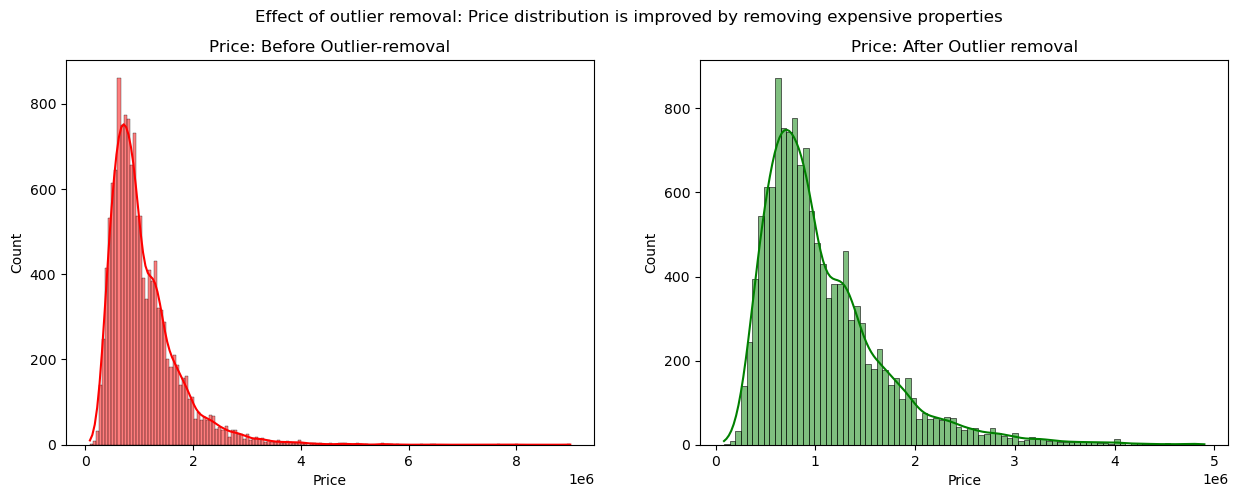

In [48]:
# Plots showing the effect of the outlier removal on the Price
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sbn.histplot(df_melb['Price'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Price: Before Outlier-removal')

sbn.histplot(df_melb_clean['Price'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Price: After Outlier removal')

fig.suptitle("Effect of outlier removal: Price distribution is improved by removing expensive properties")


plt.show()

### Landsize
Effect of the outlier removal

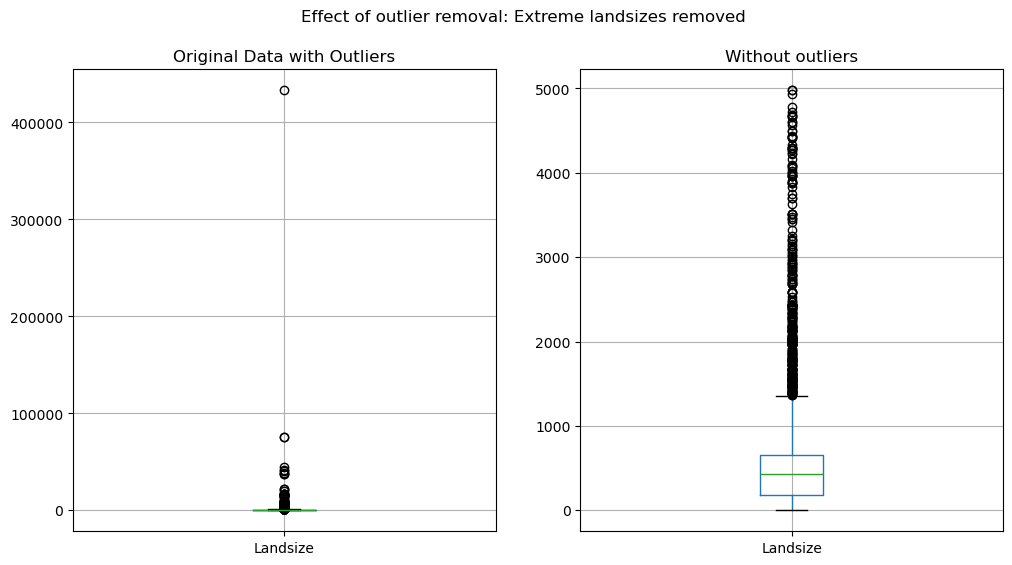

In [20]:
# Boxplots of before and after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Effect of outlier removal: Extreme landsizes removed')

df_melb.boxplot(column=['Landsize'], ax=axes[0])
axes[0].set_title('Original Data with Outliers')

df_melb_clean.boxplot(column=['Landsize'], ax=axes[1])
axes[1].set_title('Without outliers')

plt.show()

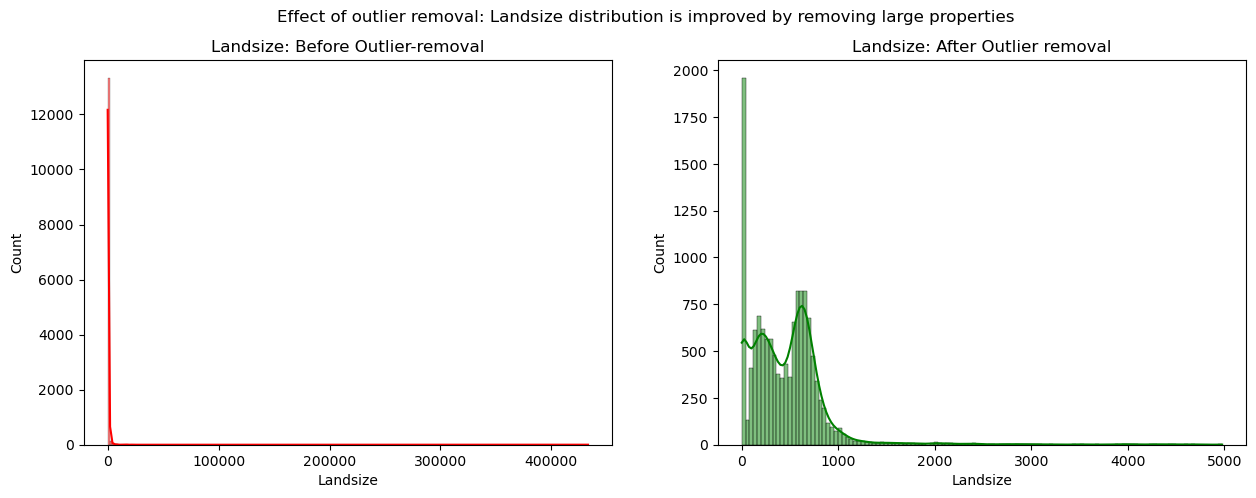

In [21]:
# Plots showing the effect of the outlier removal on the landsize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sbn.histplot(df_melb['Landsize'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Landsize: Before Outlier-removal')

sbn.histplot(df_melb_clean['Landsize'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Landsize: After Outlier removal')

fig.suptitle("Effect of outlier removal: Landsize distribution is improved by removing large properties")


plt.show()

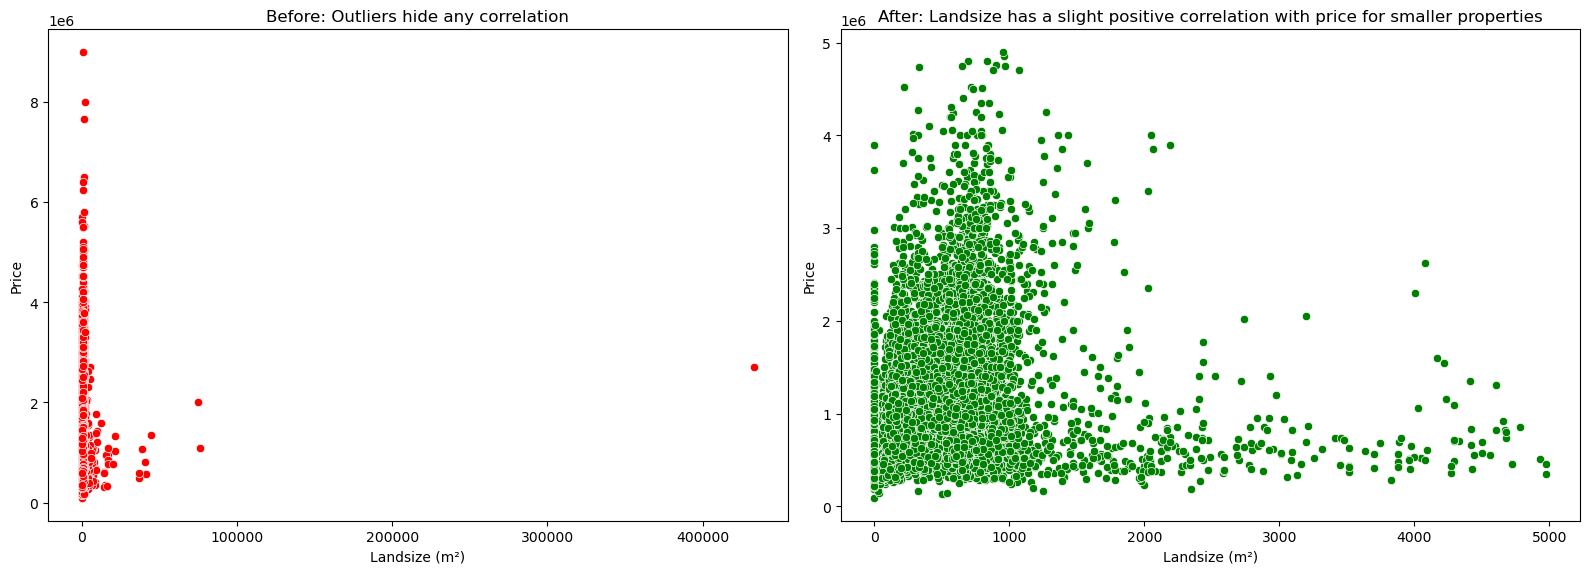

In [22]:
# Plot to see the correlation with price before and after cleaning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Before outlier removal
sbn.scatterplot(data=df_melb, x='Landsize', y='Price', ax=ax1, color='red')
ax1.set_title('Before: Outliers hide any correlation')
ax1.set_xlabel('Landsize (m²)')
ax1.set_ylabel('Price')

# After outlier removal
sbn.scatterplot(data=df_melb_clean, x='Landsize', y='Price', ax=ax2, color='green')
ax2.set_title('After: Landsize has a slight positive correlation with price for smaller properties')
ax2.set_xlabel('Landsize (m²)')
ax2.set_ylabel('Price')

plt.tight_layout()
plt.show()

### BuildingArea
Effect of outlier removal

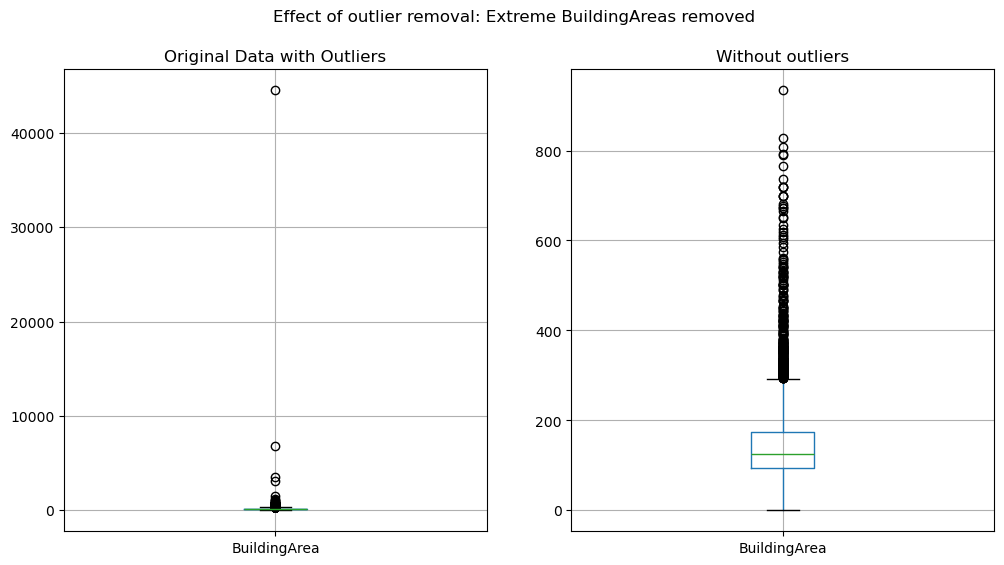

In [23]:
# Boxplots of before and after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Effect of outlier removal: Extreme BuildingAreas removed')

df_melb.boxplot(column=['BuildingArea'], ax=axes[0])
axes[0].set_title('Original Data with Outliers')

df_melb_clean.boxplot(column=['BuildingArea'], ax=axes[1])
axes[1].set_title('Without outliers')

plt.show()

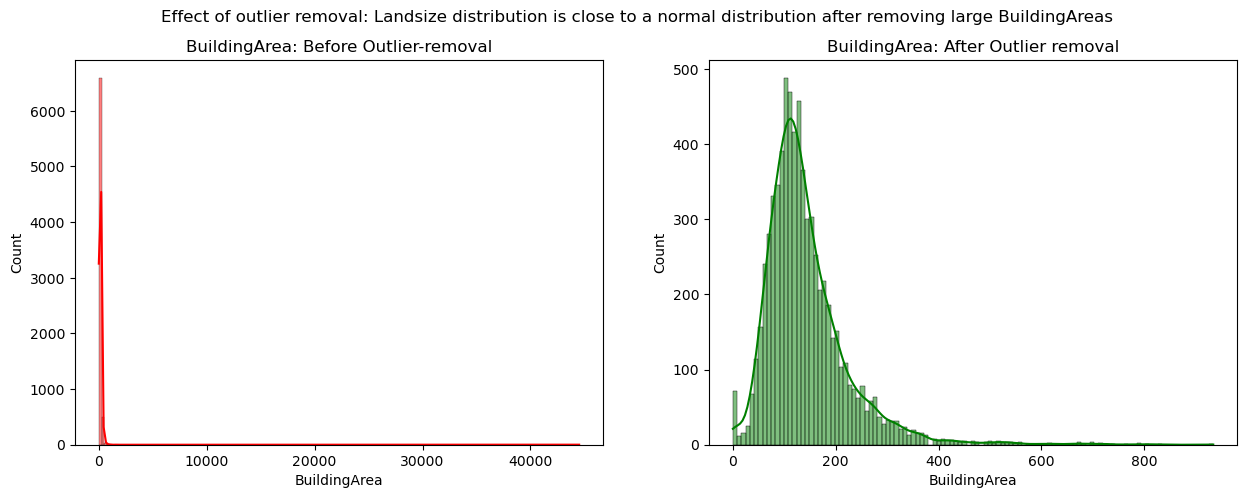

In [24]:
# Plots showing the effect of the outlier removal on the BuildingArea
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sbn.histplot(df_melb['BuildingArea'], kde=True, ax=axes[0], color='red')
axes[0].set_title('BuildingArea: Before Outlier-removal')

sbn.histplot(df_melb_clean['BuildingArea'], kde=True, ax=axes[1], color='green')
axes[1].set_title('BuildingArea: After Outlier removal')

fig.suptitle("Effect of outlier removal: Landsize distribution is close to a normal distribution after removing large BuildingAreas")


plt.show()

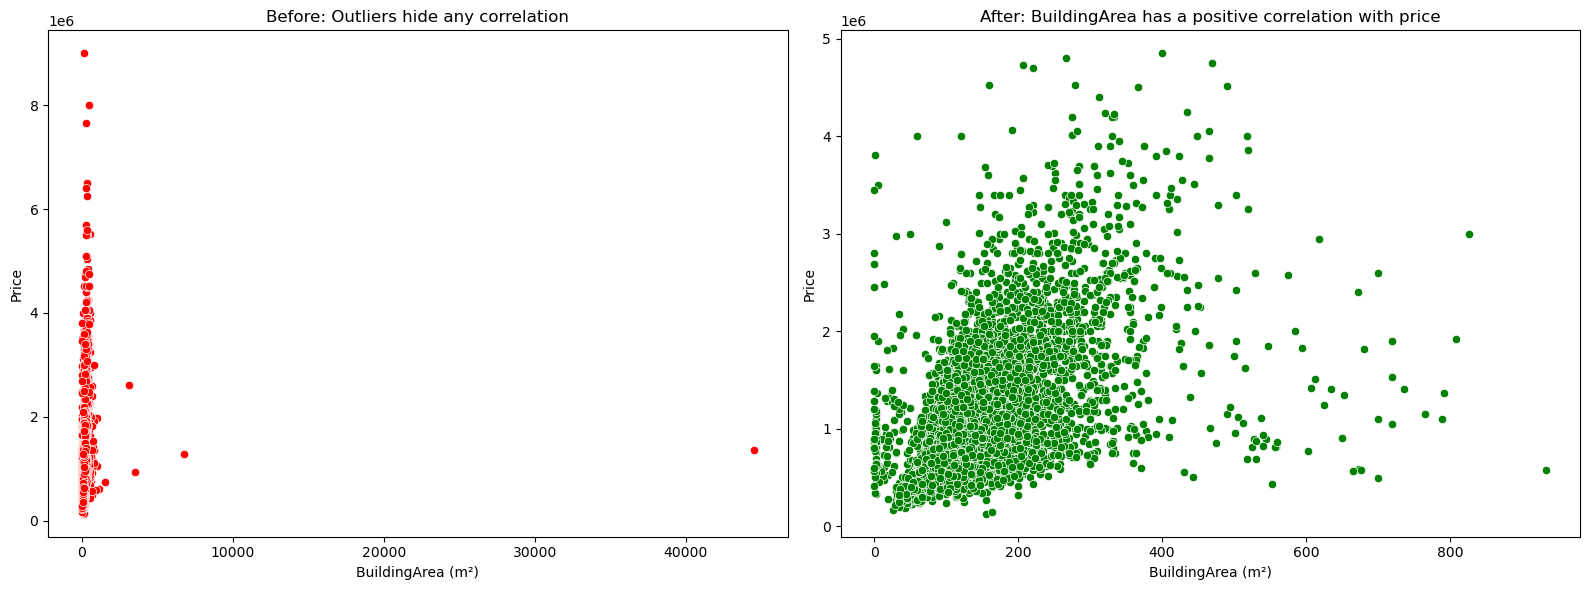

In [25]:
# Plot to see the correlation with price before and after cleaning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Before outlier removal
sbn.scatterplot(data=df_melb, x='BuildingArea', y='Price', ax=ax1, color='red')
ax1.set_title('Before: Outliers hide any correlation')
ax1.set_xlabel('BuildingArea (m²)')
ax1.set_ylabel('Price')

# After outlier removal
sbn.scatterplot(data=df_melb_clean, x='BuildingArea', y='Price', ax=ax2, color='green')
ax2.set_title('After: BuildingArea has a positive correlation with price')
ax2.set_xlabel('BuildingArea (m²)')
ax2.set_ylabel('Price')

plt.tight_layout()
plt.show()

## 3.4 Fixing Missing and Odd Values

#### 'Landsize'

In [27]:
# We will check the properties where the land size is 0
landsize_0_count = df_melb_clean[df_melb_clean['Landsize'] == 0].groupby('Type').size()

print(landsize_0_count)

Type
h     171
t     138
u    1628
dtype: int64


We can see that it is mostly townhouses and units which has a landsize of 0, which makes sense given that the land is often not owned by the individual resident.

But for the 171 houses we will treat it as an error and calculate a new landsize for those:

In [28]:
# First we will find the houses and set the lansize to NaN, so we can replace it
houses = (df_melb_clean['Type'] == 'h') & (df_melb_clean['Landsize'] == 0)
df_melb_clean.loc[houses, 'Landsize'] = np.nan

# We will replace the NaN's with the median of similar houses in the same suburbs and a global median if there is still missing values
land_median = df_melb_clean[df_melb_clean['Type'] == 'h'].groupby('Suburb')['Landsize'].transform('median')

df_melb_clean['Landsize'] = df_melb_clean['Landsize'].fillna(land_median).fillna(df_melb_clean['Landsize'].median())

In [29]:
# We will check if there are still houses without a lansize of 0
landsize_0_count = df_melb_clean[df_melb_clean['Landsize'] == 0].groupby('Type').size()

print(landsize_0_count)

Type
t     138
u    1628
dtype: int64


We can see that it is now only townhouses and units with at landsize o 0 remaining

#### 'Bathroom'

By law in Australia a residential property must have a bathroom, we will therefore treat bathroom == 0 as an error and replace it

In [30]:
# First we will check how many are missing a bathroom
zero_bathrooms = df_melb_clean[df_melb_clean['Bathroom'] == 0]

# Given that it is only 34, it seems even more likely that it is an input error 
# and not at actual property with 0 Bathrooms
print(zero_bathrooms.shape)

(34, 20)


In [31]:
# 0 will be replaced with NaN
df_melb_clean.loc[df_melb_clean['Bathroom'] == 0, 'Bathroom'] = np.nan

# Calculate the median number of bathrooms by number of rooms
bathroom_median = df_melb_clean.groupby('Rooms')['Bathroom'].transform('median')

# Replace the NaN's
df_melb_clean['Bathroom'] = df_melb_clean['Bathroom'].fillna(bathroom_median)

# Check if there is still NaN's
print(df_melb_clean[df_melb_clean['Bathroom'] == 0].shape)

(0, 20)


#### 'Cars'
For the 62 missing car values we will use the median to fill the missing  as you can not have 1.4 car spaces

In [32]:
median_cars = df_melb_clean['Car'].median()
df_melb_clean['Car'] = df_melb_clean['Car'].fillna(median_cars)

#### 'BuildingArea'

In [33]:
# We will check the properties where the building area is 0
m2_0_count = df_melb_clean[df_melb_clean['BuildingArea'] == 0].groupby('Type').size()

print(m2_0_count)

Type
h    14
t     3
dtype: int64


In [34]:
# Replace the 0's with NAN
df_melb_clean.loc[m2_0_count, 'BuildingArea'] = np.nan

In [35]:
# First we will check that the rows with missing BuildingArea are not empty lots without buildings (development sites)
df_melb_clean['Type'].unique()

<ArrowStringArray>
['h', 'u', 't']
Length: 3, dtype: str

In [36]:
# Check to see how the NaN's are distributed among the types of properties
df_melb_clean[df_melb_clean['BuildingArea'].isna()]['Type'].value_counts()

Type
h    4572
u    1416
t     427
Name: count, dtype: int64

So we can conclude that the rows with missing values are not just empty lots without houses.
Given that nearly half of the rows are missing the BuildingArea we will not drop it but fill it with the median for similar properties based on their type and number of rooms:

In [37]:
# Calculate the median for each group
grouped_median_m2 = df_melb_clean.groupby(['Type', 'Rooms'])['BuildingArea'].transform('median')

# Fill in the missing values, first with the grouped median and then with a global median if there are still missing values
df_melb_clean['BuildingArea'] = df_melb_clean['BuildingArea'].fillna(grouped_median_m2).fillna(df_melb_clean['BuildingArea'].median())

#### 'YearBuilt'

Earlier we found a house supposedly from 1196, so before we fill in the missing values for 'YearBuilt' we will investigate how many odd values we have in 'YearBuilt' and fix those

In [38]:
old_houses = df_melb_clean[df_melb_clean['YearBuilt'] < 1800]

In [39]:
# We can see there only is one property from before 1800
# A quick search of the adress shows that it definitely is not from 1196 and therefore an error
old_houses.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
9968,Mount Waverley,5 Armstrong St,3,h,1200000.0,VB,McGrath,24/06/2017,14.2,3149.0,1.0,4.0,807.0,117.0,1196.0,Monash,-37.86788,145.12121,Eastern Metropolitan,13366.0


In [40]:
# We will replace the value of the odd house with NaN and then fill it in after
df_melb_clean.loc[9968, 'YearBuilt'] = np.nan

Now that 'YearBuilt' is clean from error we will replace the NaN's:

In [41]:
# We calculate the median build year for each suburb
grouped_median_year = df_melb_clean.groupby(['Suburb'])['YearBuilt'].transform('median')

# Fill in the missing values, first with the grouped median and then with th gloibal median if there is still missing values
df_melb_clean['YearBuilt'] = df_melb_clean['YearBuilt'].fillna(grouped_median_year).fillna(df_melb_clean['YearBuilt'].median())

#### 'CouncilArea'

In [42]:
# We will which suburbs are missing a CouncilArea to see if there is a pattern in som suburbs
missing_council = df_melb_clean[df_melb_clean['CouncilArea'].isna()]
missing_council['Suburb'].value_counts()

Suburb
Reservoir        36
Glen Iris        23
Sunbury          21
Balwyn North     20
Glen Waverley    19
                 ..
Kings Park        1
Kooyong           1
Langwarrin        1
Monbulk           1
Tarneit           1
Name: count, Length: 261, dtype: int64

We can see that out of 314 Suburbs, 263 different Suburbs have a missing CouncilArea.

Our options:
* Map each suburb to a councilArea
* Replace the NaN's with the most common CouncilArea for each Suburb
* Drop the column as we already have enough geographical data in 'Address', 'Suburb', 'Regionname', 'Lattitude' and 'Longitude'

We will in the first iteration drop the column and see how our ML models perform

In [43]:
df_melb_clean = df_melb_clean.drop(columns = 'CouncilArea')

#### Final Check

In [44]:
# Check to see if there are still missing values
df_melb_clean.isna().sum()

Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64

In [45]:
df_melb_clean.describe()

,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13489.000000,1.348900e+04,13489.000000,13489.000000,13489.000000,13489.000000,13489.000000,13489.000000,13489.000000,13489.000000,13489.000000,13489.000000
mean,2.937505,1.068805e+06,10.154089,3105.012010,1.533917,1.610053,464.992809,136.750983,1964.366780,-37.809164,144.995213,7446.913040
std,0.952704,6.096630e+05,5.838415,90.347959,0.683907,0.959472,435.125713,68.579529,30.850811,0.079304,0.103850,4376.657346
min,1.000000,8.500000e+04,0.000000,3000.000000,1.000000,0.000000,0.000000,0.000000,1830.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.200000,3044.000000,1.000000,1.000000,184.000000,96.000000,1950.000000,-37.857000,144.929200,4380.000000
50%,3.000000,9.020000e+05,9.200000,3084.000000,1.000000,2.000000,446.000000,130.000000,1970.000000,-37.802100,145.000100,6543.000000
75%,3.000000,1.328000e+06,13.000000,3148.000000,2.000000,2.000000,650.000000,166.000000,1981.000000,-37.756100,145.058500,10331.000000
max,10.000000,4.900000e+06,47.400000,3977.000000,8.000000,10.000000,4977.000000,934.000000,2018.000000,-37.408530,145.526350,21650.000000


## 3.5 Feature Engineering

In [46]:
# Calculate price per m2 for each row
df_melb_clean["Price_per_m2"] = df_melb_clean["Price"] / df_melb_clean["BuildingArea"]

In [47]:
# Calculate the age for each row
df_melb_clean["Age"] = 2026 - df_melb_clean["YearBuilt"]

## 3.6 Data Transformation

### Encoding

### Scaling

# 4. Data Exploration

## 4.1 EDA

## 4.2 Correlations

## 4.3 Descriptive Statistics

## 4.4 Inferential Statistics

# 5. Data Modelling

# 6. Presentation